In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [18]:
hourly = pd.read_csv("../data/FremontHourly.csv", index_col="Date", parse_dates=True)#, date_format="%Y/%m/%d")


/tmp/ipykernel_311606/1541568872.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hourly = pd.read_csv("../data/FremontHourly.csv", index_col="Date", parse_dates=True)#, date_format="%Y/%m/%d")


In [35]:
# change FremontBridge{NB,SB} -> -> northbound, southbound
hourly.columns = ["northbound", "southbound"]
hourly["total"] = hourly["northbound"] + hourly["southbound"]

In [36]:
# Resampling the data into lower frequencies : Daily and weekly
daily = hourly.resample("D").sum()
weekly = daily.resample("W").sum()

In [12]:
hourly.resample?

Signature:
hourly.resample(
    rule,
    axis: 'Axis | lib.NoDefault' = <no_default>,
    closed: "Literal['right', 'left'] | None" = None,
    label: "Literal['right', 'left'] | None" = None,
    convention: "Literal['start', 'end', 's', 'e']" = 'start',
    kind: "Literal['timestamp', 'period'] | None | lib.NoDefault" = <no_default>,
    on: 'Level | None' = None,
    level: 'Level | None' = None,
    origin: 'str | TimestampConvertibleTypes' = 'start_day',
    offset: 'TimedeltaConvertibleTypes | None' = None,
    group_keys: 'bool_t' = False,
) -> 'Resampler'
Docstring:
Resample time-series data.

Convenience method for frequency conversion and resampling of time series.
The object must have a datetime-like index (`DatetimeIndex`, `PeriodIndex`,
or `TimedeltaIndex`), or the caller must pass the label of a datetime-like
series/index to the ``on``/``level`` keyword parameter.

Parameters
----------
rule : DateOffset, Timedelta or str
    The offset string or object representing targ

In [38]:
weekly.head()

,northbound,southbound,total
Date,,,
2012-10-07,8160.0,8070.0,16230.0
2012-10-14,8116.0,8679.0,16795.0
2012-10-21,7563.0,7946.0,15509.0
2012-10-28,6536.0,6901.0,13437.0
2012-11-04,5786.0,6408.0,12194.0


Text(0, 0.5, 'Weekly riders')

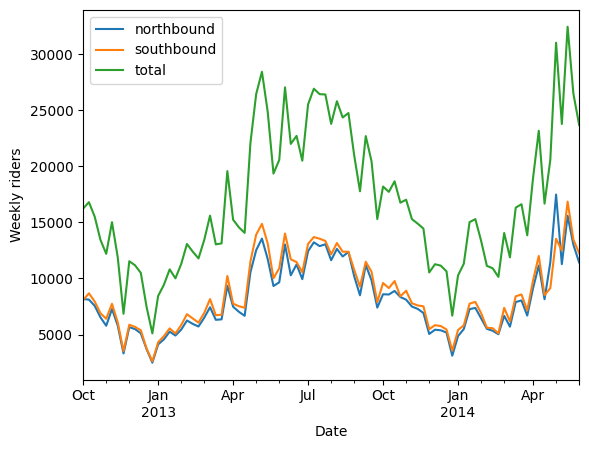

In [40]:
weekly.plot()
plt.ylabel("Weekly riders")

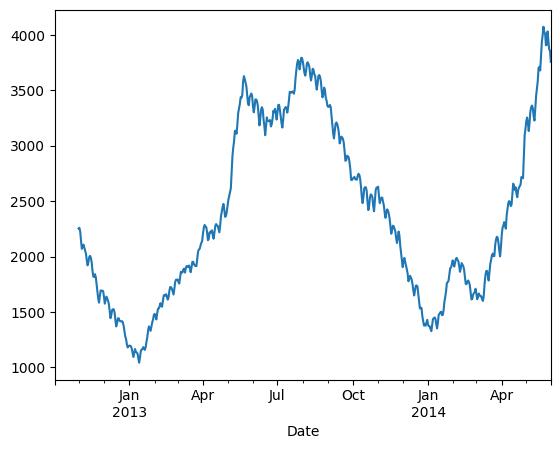

In [47]:
# A rolling mean with window or moving average, to help remove artifacts
daily["total"].rolling(30).mean().plot();

## time to model the variation shown by seasonality
### step one:  Account for daylight hours
1. Compute the number of hours of daylight.
2. Use this number to de-trend the data

In [57]:
# return the hours in the day for a given day of the year
from datetime import datetime
def daylight_hours(date, axis=23.44, latitude=47.61):
    """Compute the number of hours of daylight for the given date"""
    diff = date - datetime(2000, 12, 21)
    day = diff.total_seconds() / 24. / 3600
    day %= 365.25
    m = 1.0 - np.tan(np.radians(latitude)) * np.tan(np.radians(axis) * np.cos(day * np.pi / 182.625))
    m = max(0, min(m, 2))
    return 24.0 * np.degrees(np.arccos(1 -m)) / 180.0

weekly["daylight"] =  weekly.index.map(daylight_hours)
daily["daylight"] = daily.index.map(daylight_hours)

In [55]:
weekly.index.map(daylight_hours)

Index([11.045208198323838, 10.644851500181554, 10.255304845221417,
        9.881095472004374,  9.527645257889892,  9.201316153036737,
        8.909312391865852,  8.659391241493358,  8.459353105224464,
        8.316329377096082,  8.235960149477135,  8.221629282759691,
        8.273957123800518,  8.390703582211895,   8.56711239109441,
        8.796589420987223,  9.071524331824891,  9.384065993290546,
        9.726725160571114,  10.09275677897858, 10.476334459915442,
       10.872560237618181,  11.27735923649674, 11.687301971896474,
        12.09938553942396, 12.510794238222273, 12.918652711145592,
        13.31978137041863, 13.710464934730997, 14.086250272405449,
       14.441798956773182, 14.770831470793084, 15.066210149186254,
       15.320209684132633,  15.52500714933817, 15.673378623405323,
       15.759517499860895, 15.779812695513028,  15.73338647434647,
       15.622231402993268, 15.450902955437599, 15.225863912240632,
       14.954667218757407,  14.64517011511446, 14.304913000418

In [59]:
daily.head()

,northbound,southbound,total,daylight
Date,,,,
2012-10-02,1165.0,773.0,1938.0,11.335681
2012-10-03,1761.0,1760.0,3521.0,11.277359
2012-10-04,1767.0,1708.0,3475.0,11.219142
2012-10-05,1590.0,1558.0,3148.0,11.161038
2012-10-06,926.0,1080.0,2006.0,11.103056


In [56]:
weekly.index

DatetimeIndex(['2012-10-07', '2012-10-14', '2012-10-21', '2012-10-28',
               '2012-11-04', '2012-11-11', '2012-11-18', '2012-11-25',
               '2012-12-02', '2012-12-09', '2012-12-16', '2012-12-23',
               '2012-12-30', '2013-01-06', '2013-01-13', '2013-01-20',
               '2013-01-27', '2013-02-03', '2013-02-10', '2013-02-17',
               '2013-02-24', '2013-03-03', '2013-03-10', '2013-03-17',
               '2013-03-24', '2013-03-31', '2013-04-07', '2013-04-14',
               '2013-04-21', '2013-04-28', '2013-05-05', '2013-05-12',
               '2013-05-19', '2013-05-26', '2013-06-02', '2013-06-09',
               '2013-06-16', '2013-06-23', '2013-06-30', '2013-07-07',
               '2013-07-14', '2013-07-21', '2013-07-28', '2013-08-04',
               '2013-08-11', '2013-08-18', '2013-08-25', '2013-09-01',
               '2013-09-08', '2013-09-15', '2013-09-22', '2013-09-29',
               '2013-10-06', '2013-10-13', '2013-10-20', '2013-10-27',
      

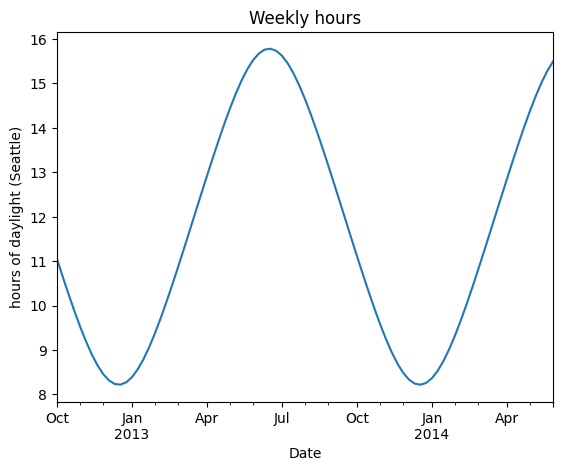

In [62]:
weekly["daylight"].plot(title="Weekly hours")
plt.ylabel("hours of daylight (Seattle)");

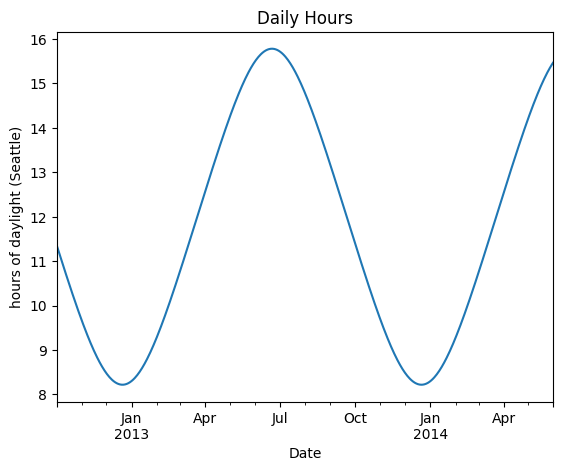

In [61]:
daily["daylight"].plot(title="Daily Hours")
plt.ylabel("hours of daylight (Seattle)");

Text(0, 0.5, 'weekly bike traffic')

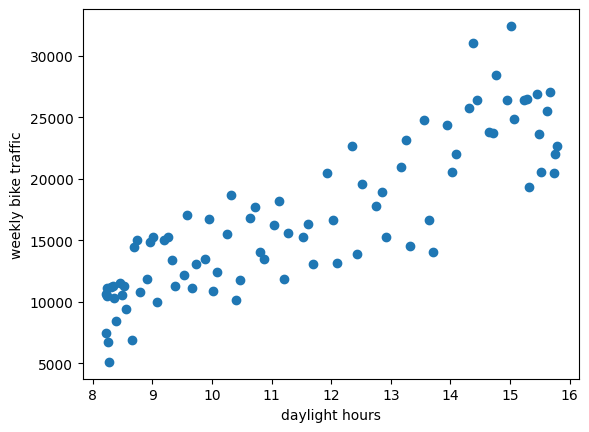

In [63]:
# Let's see how the weekly trend looks
plt.scatter(weekly["daylight"], weekly["total"])
plt.xlabel("daylight hours")
plt.ylabel("weekly bike traffic")

There is a clear trend but the wide scatter also suggests other influences.

### Linear fit to the data

In [65]:
from sklearn.linear_model import LinearRegression

In [74]:
# X = weekly["daylight"].to_numpy() # gives you 1D
Xx = weekly[["daylight"]].to_numpy() # gives you 2D which the regression object requires

In [80]:
X.size


87

In [78]:
Xx.size

87

In [81]:
y = weekly["total"]
y

Date
2012-10-07    16230.0
2012-10-14    16795.0
2012-10-21    15509.0
2012-10-28    13437.0
2012-11-04    12194.0
               ...   
2014-05-04    31006.0
2014-05-11    23759.0
2014-05-18    32427.0
2014-05-25    26464.0
2014-06-01    23672.0
Freq: W-SUN, Name: total, Length: 87, dtype: float64

In [84]:
clf = LinearRegression(fit_intercept=True).fit(Xx,y)

In [86]:
weekly["daylight_trend"] = clf.predict(Xx)
weekly["daylight_corrected_total"] = weekly["total"] - weekly["daylight_trend"] + weekly["daylight_trend"].mean()
weekly

,northbound,southbound,total,daylight,daylight_trend,daylight_corrected_total
Date,,,,,,
2012-10-07,8160.0,8070.0,16230.0,11.045208,15786.856272,17274.028786
2012-10-14,8116.0,8679.0,16795.0,10.644852,14963.542880,18662.342178
2012-10-21,7563.0,7946.0,15509.0,10.255305,14162.459798,18177.425260
2012-10-28,6536.0,6901.0,13437.0,9.881095,13392.917063,16874.967994
2012-11-04,5786.0,6408.0,12194.0,9.527645,12666.064494,16358.820563
...,...,...,...,...,...,...
2014-05-04,17474.0,13532.0,31006.0,14.380060,22644.810584,25192.074474
2014-05-11,11276.0,12483.0,23759.0,14.714328,23332.217261,17257.667797
2014-05-18,15580.0,16847.0,32427.0,15.016272,23953.148011,25304.737046


Text(0, 0.5, 'weekly bicycle traffic')

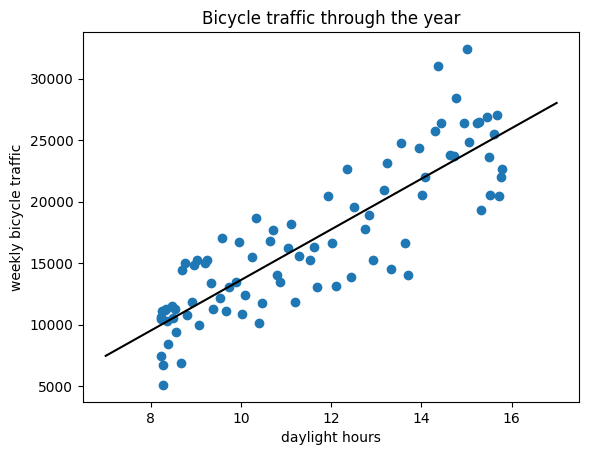

In [89]:
xfit = np.linspace(7, 17)
yfit = clf.predict(xfit[:, None])
plt.scatter(weekly["daylight"], weekly["total"])
plt.plot(xfit, yfit, "-k")
plt.title("Bicycle traffic through the year")
plt.xlabel("daylight hours")
plt.ylabel("weekly bicycle traffic")

In [112]:
clf.coef_[0], clf.intercept_

(np.float64(2056.449649894534), np.float64(-6927.058260881346))

In [114]:
10.644852 * 2056.449649894534 + np.float64(-6927.058260881346)

np.float64(14963.543907697785)

### Model interpretation
The coefficient tells us that on average each extra daylight hour leads to 2056 more riders per week across the bridge.

### Detrending the daylight and plotting


Text(0, 0.5, 'adjusted weekly riders')

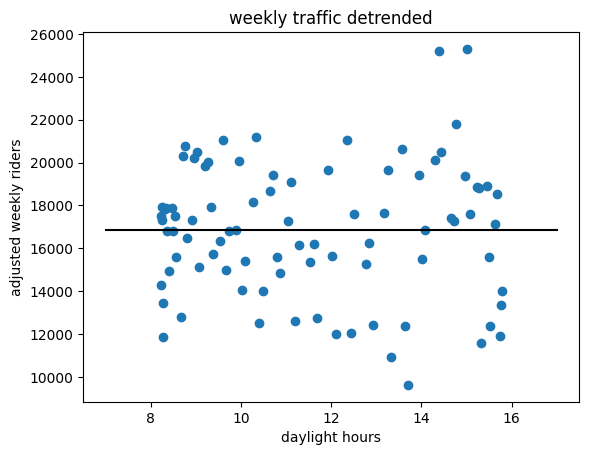

In [105]:
plt.scatter(weekly["daylight"], weekly["total"] - weekly["daylight_trend"] + weekly["daylight_trend"].mean())
plt.plot(xfit, weekly["daylight_trend"].mean() + 0 * yfit, "-k")
plt.title("weekly traffic detrended")
plt.xlabel("daylight hours")
plt.ylabel("adjusted weekly riders")

Text(0.5, 1.0, 'weekly traffic detrended')

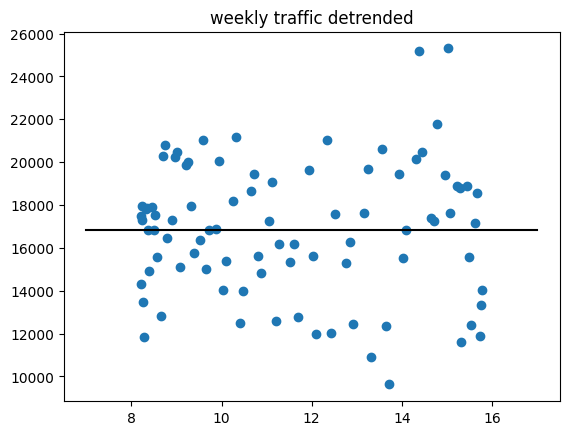

In [102]:
plt.scatter(weekly["daylight"], weekly["daylight_corrected_total"])
plt.plot(xfit, weekly["daylight_trend"].mean() + 0 * yfit, "-k")
plt.title("weekly traffic detrended")

The component of the data that was correlated to the number of hours in a day was removed. 
    This has resulted to the shape of the plots that we see.

Text(0, 0.5, 'total weekly riders')

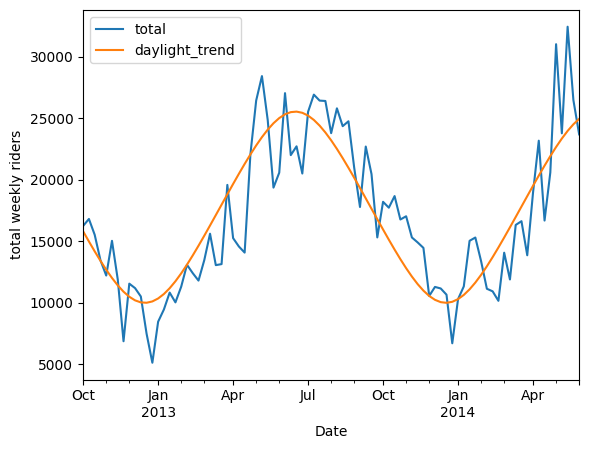

In [117]:
# Riders with trend vs day of the year
weekly[["total", "daylight_trend"]].plot()# plot(subplots=True)
plt.ylabel("total weekly riders")

Root mean square about trend: 3100 riders


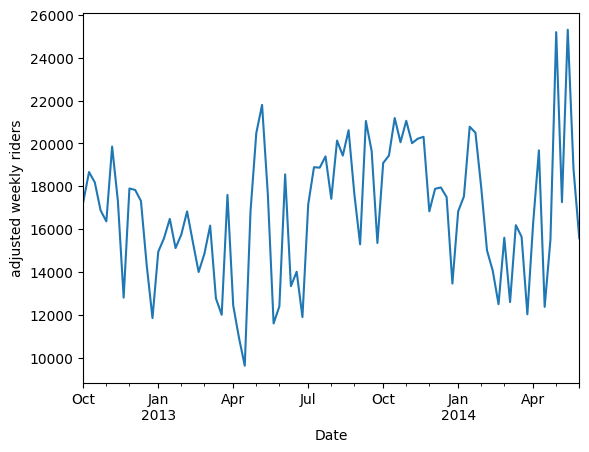

In [118]:
# and the actual detrended total riders
weekly["daylight_corrected_total"].plot()
rms = np.std(weekly["daylight_corrected_total"])
plt.ylabel("adjusted weekly riders")
print("Root mean square about trend: {0:.0f} riders".format(rms))

This shows us how the cycling has evolved over time, taking into account the seasonal variation (number of daylight hours).

## Accounting for day of week

In [123]:
days = ["Mon", "Tues", "Wed", "Thurs", "Fri", "Sat", "Sun"]
daily["dayofweek"] = daily.index.dayofweek

In [124]:
daily

,northbound,southbound,total,daylight,dayofweek
Date,,,,,
2012-10-02,1165.0,773.0,1938.0,11.335681,1
2012-10-03,1761.0,1760.0,3521.0,11.277359,2
2012-10-04,1767.0,1708.0,3475.0,11.219142,3
2012-10-05,1590.0,1558.0,3148.0,11.161038,4
2012-10-06,926.0,1080.0,2006.0,11.103056,5
...,...,...,...,...,...
2014-05-27,2470.0,2562.0,5032.0,15.344641,1
2014-05-28,1930.0,2078.0,4008.0,15.376320,2
2014-05-29,2287.0,2300.0,4587.0,15.406955,3


In [128]:
grpday = daily.groupby("dayofweek")["total"].mean()
grpday.index = days

In [130]:
grpday

Mon      2806.627907
Tues     2995.931034
Wed      2979.149425
Thurs    2793.931034
Fri      2588.402299
Sat      1408.885057
Sun      1305.220930
Name: total, dtype: float64

Text(0, 0.5, 'average daily crossings')

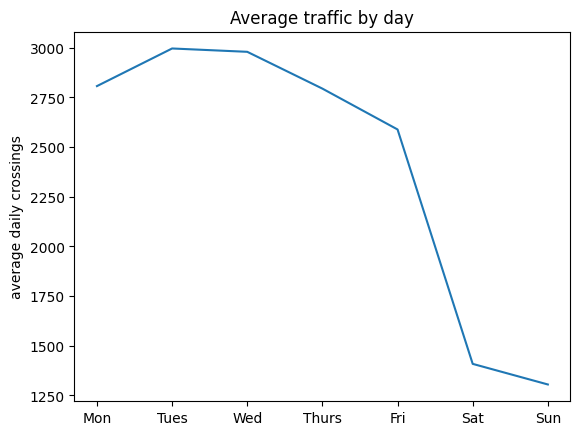

In [131]:
grpday.plot(title="Average traffic by day")
plt.ylabel("average daily crossings")

### Detrend the daily ride counts 
- add a daily variable for each day of the week

In [132]:
# One hot encoding for dayofweek
for i in range(7):
    daily[days[i]] = (daily.index.dayofweek == i).astype(float)

daily

,northbound,southbound,total,daylight,dayofweek,Mon,Tues,Wed,Thurs,Fri,Sat,Sun
Date,,,,,,,,,,,,
2012-10-02,1165.0,773.0,1938.0,11.335681,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2012-10-03,1761.0,1760.0,3521.0,11.277359,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2012-10-04,1767.0,1708.0,3475.0,11.219142,3,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2012-10-05,1590.0,1558.0,3148.0,11.161038,4,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2012-10-06,926.0,1080.0,2006.0,11.103056,5,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2014-05-27,2470.0,2562.0,5032.0,15.344641,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2014-05-28,1930.0,2078.0,4008.0,15.376320,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2014-05-29,2287.0,2300.0,4587.0,15.406955,3,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [135]:
# detrend on days of week and daylight
X = daily[days + ["daylight"]].to_numpy()
y = daily["total"]
clf = LinearRegression().fit(X, y)

<Axes: xlabel='Date'>

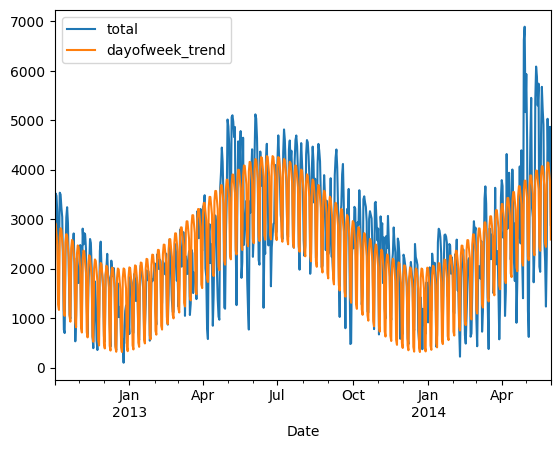

In [139]:
daily["dayofweek_trend"] = clf.predict(X)
daily[["total", "dayofweek_trend"]].plot()#color=["blue", "g"])

Detrending is simply removing the factor in a variable that accounts for much of its variability within the period and use instead the factors that remain fairly constant within that same period.

To explain more, the plot in orange is the `day of week` trend, obtained from the daylight hours and dayofweek.

The `total` which is in blue encompasses both the effect of daylight hours and the day of the week thereby leading to visible trends in the data. To detrend this, we would therefore subtract the `dayofweek trend` from the `total`. 

Root mean squared: 698


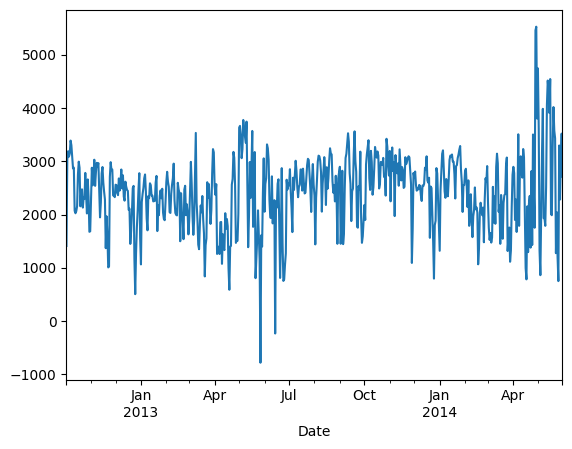

In [143]:
daily["dayofweek_corrected"] = daily["total"] - daily["dayofweek_trend"] + daily["dayofweek_trend"].mean()
rms = np.std(daily["dayofweek_corrected"])
print("Root mean squared: {0:.0f}".format(rms))
daily["dayofweek_corrected"].plot();

This is what it looks like when we account for dayofweek and hours of daylight.

Therefore we can infer that there are some other factors influencing the fluctuation we're seeing.

## Temperature and precipitation effects

For this, we're using the data from NCDC around the SeaTac Airport.

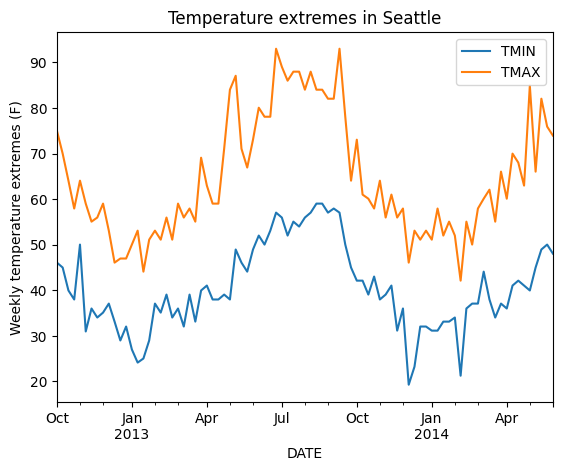

In [151]:
weather = pd.read_csv("../data/SeaTacWeather.csv", index_col="DATE", 
                      parse_dates=True, usecols=[2,3,6,7])

# temperature conversion from 1/10ºc to F
weather["TMIN"] = 0.18 * weather["TMIN"] + 32
weather["TMAX"] = 0.18 * weather["TMAX"] + 32

# precipitation conversion from 1/10 mm to inches
weather["PRCP"] /= 254

# QUICK view
weather["TMIN"].resample("W").min().plot()
weather["TMAX"].resample("W").max().plot()
plt.ylabel("Weekly temperature extremes (F)")
plt.title("Temperature extremes in Seattle")
plt.legend()


Text(0, 0.5, 'Weekly precipitation (inches)')

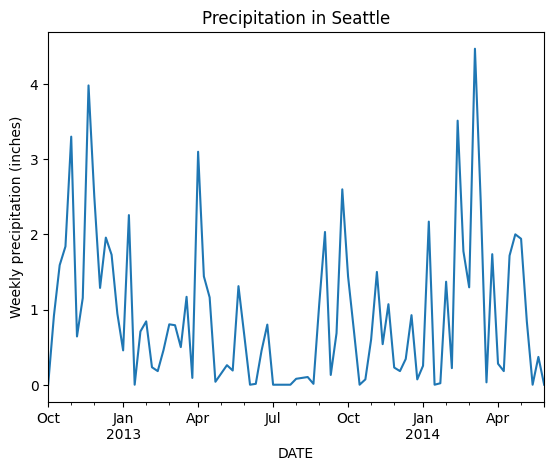

In [152]:
# Precipitation
weather["PRCP"].resample("W").sum().plot(title="Precipitation in Seattle")
plt.ylabel("Weekly precipitation (inches)")

Now to join both the weather and the bicycle datasets on the daily scale.

In [155]:
weather

,PRCP,TMAX,TMIN
DATE,,,
2012-10-01,0.0,73.94,48.02
2012-10-02,0.0,64.04,50.00
2012-10-03,0.0,66.02,46.04
2012-10-04,0.0,66.02,46.94
2012-10-05,0.0,71.06,48.02
...,...,...,...
2014-05-28,0.0,66.02,50.00
2014-05-29,0.0,66.02,51.98
2014-05-30,0.0,69.08,48.02


In [153]:
dailyboth = daily.join(weather)

In [154]:
dailyboth

,northbound,southbound,total,daylight,dayofweek,Mon,Tues,Wed,Thurs,Fri,Sat,Sun,dayofweek_trend,dayofweek_corrected,PRCP,TMAX,TMIN
Date,,,,,,,,,,,,,,,,,
2012-10-02,1165.0,773.0,1938.0,11.335681,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2940.701542,1409.632890,0.0,64.04,50.00
2012-10-03,1761.0,1760.0,3521.0,11.277359,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2904.393958,3028.940474,0.0,66.02,46.04
2012-10-04,1767.0,1708.0,3475.0,11.219142,3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2699.638453,3187.695979,0.0,66.02,46.94
2012-10-05,1590.0,1558.0,3148.0,11.161038,4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2474.564863,3085.769569,0.0,71.06,48.02
2012-10-06,926.0,1080.0,2006.0,11.103056,5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1275.498498,3142.835934,0.0,75.02,46.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-05-27,2470.0,2562.0,5032.0,15.344641,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4148.371298,3295.963133,0.0,68.00,50.00
2014-05-28,1930.0,2078.0,4008.0,15.376320,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4139.175905,2281.158526,0.0,66.02,50.00
2014-05-29,2287.0,2300.0,4587.0,15.406955,3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3961.186669,3038.147763,0.0,66.02,51.98


In [159]:
columns = days + ["daylight", "TMIN", "TMAX", "PRCP"]

X = dailyboth[columns]
y = dailyboth["total"]

clf = LinearRegression().fit(X, y)
dailyboth["overall_trend"] = clf.predict(X)

In [161]:
dailyboth

,northbound,southbound,total,daylight,dayofweek,Mon,Tues,Wed,Thurs,Fri,Sat,Sun,dayofweek_trend,dayofweek_corrected,PRCP,TMAX,TMIN,overall_trend
Date,,,,,,,,,,,,,,,,,,
2012-10-02,1165.0,773.0,1938.0,11.335681,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2940.701542,1409.632890,0.0,64.04,50.00,3185.762304
2012-10-03,1761.0,1760.0,3521.0,11.277359,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2904.393958,3028.940474,0.0,66.02,46.04,3517.815234
2012-10-04,1767.0,1708.0,3475.0,11.219142,3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2699.638453,3187.695979,0.0,66.02,46.94,3312.103069
2012-10-05,1590.0,1558.0,3148.0,11.161038,4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2474.564863,3085.769569,0.0,71.06,48.02,3353.149213
2012-10-06,926.0,1080.0,2006.0,11.103056,5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1275.498498,3142.835934,0.0,75.02,46.04,2520.764593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-05-27,2470.0,2562.0,5032.0,15.344641,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4148.371298,3295.963133,0.0,68.00,50.00,4010.577882
2014-05-28,1930.0,2078.0,4008.0,15.376320,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4139.175905,2281.158526,0.0,66.02,50.00,3921.490418
2014-05-29,2287.0,2300.0,4587.0,15.406955,3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3961.186669,3038.147763,0.0,66.02,51.98,3681.324833


<Axes: xlabel='Date', ylabel='daily bicycle traffic'>

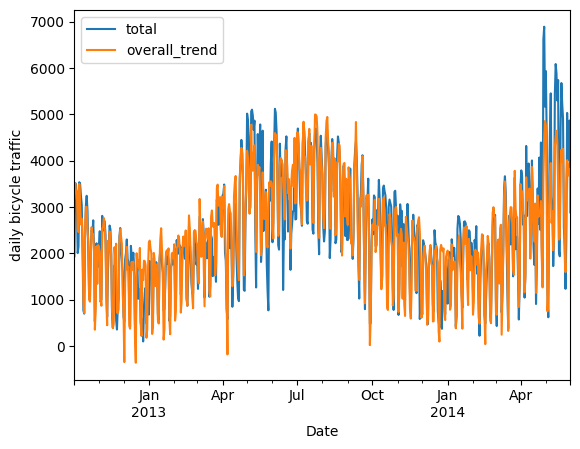

In [163]:
dailyboth[["total", "overall_trend"]].plot(ylabel="daily bicycle traffic")

As usual we de-trend the data 

In [165]:
dailyboth["overall_corrected"] = dailyboth["total"] - dailyboth["overall_trend"] + dailyboth["overall_trend"].mean()

rms: 520.00


<Axes: xlabel='Date', ylabel='corrected daily bicycle traffic'>

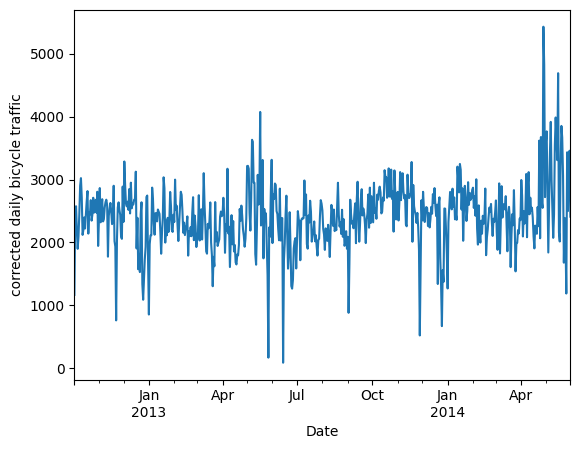

In [169]:
rms = np.std(dailyboth["overall_corrected"])
print("rms: {0:.2f}".format(rms))
dailyboth["overall_corrected"].plot(ylabel="corrected daily bicycle traffic")

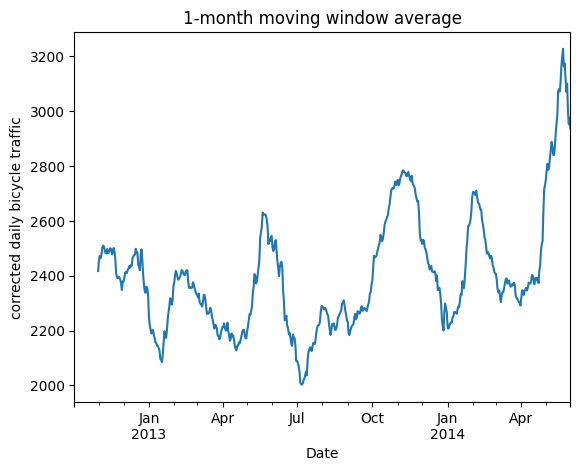

In [170]:
dailyboth["overall_corrected"].rolling(30).mean().plot(ylabel="corrected daily bicycle traffic",
                                                       title="1-month moving window average");

 ## Accounting for steady increase or decrease of riders

In [171]:
dailyboth["daycount"] = np.arange(len(dailyboth))

In [173]:
columns = days + ["daycount", "daylight", "TMIN", "TMAX", "PRCP"]
X = dailyboth[columns]
y = dailyboth["total"]

final_model = LinearRegression().fit(X, y)
dailyboth["final_trend"] = final_model.predict(X)

dailyboth["final_corrected"] = dailyboth["total"] - dailyboth["final_trend"] + dailyboth["final_trend"].mean()

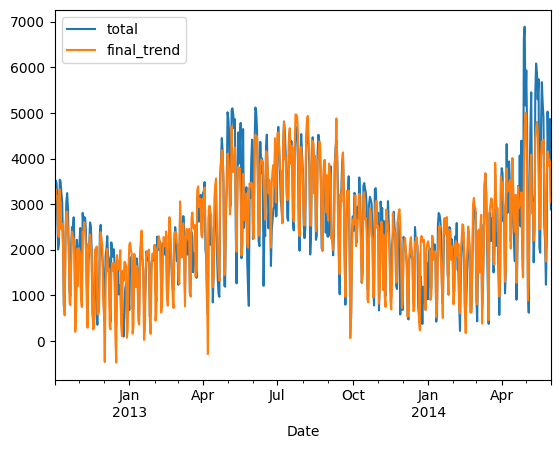

In [175]:
dailyboth["total"].plot()
dailyboth["final_trend"].plot()
plt.legend()

rms = 508.72


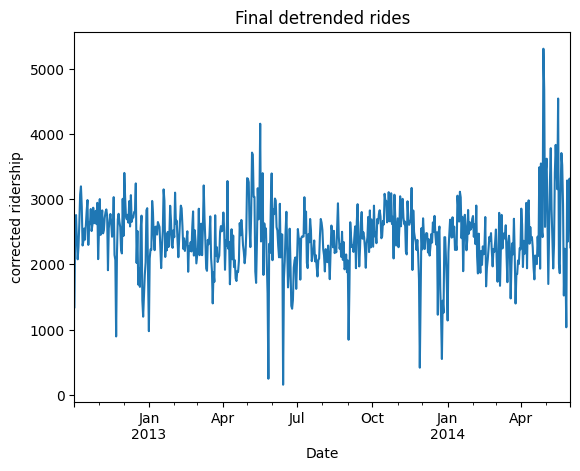

In [177]:
dailyboth["final_corrected"].plot(title="Final detrended rides", ylabel="corrected ridership")
print("rms = {0:.2f}".format(np.std(dailyboth["final_corrected"])))

## Final model

In [183]:
# Compute the error covariance

vy = np.sum((y - dailyboth["final_trend"]) ** 2) / len(y)
X2 = np.hstack([X, np.ones((X.shape[0], 1))])
C = vy * np.linalg.inv(np.dot(X2.T, X2))
var = C.diagonal()

In [185]:
var

array([1.82113307e+18, 1.82113307e+18, 1.82113307e+18, 1.82113307e+18,
       1.82113307e+18, 1.82113307e+18, 1.82113307e+18, 1.46357535e-02,
       1.82268670e+02, 2.42098892e+01, 1.60189417e+01, 6.28795009e+03,
       1.82113307e+18])

## How does rain affect ridership?


In [189]:
ind = columns.index("PRCP")
slope = final_model.coef_[ind]
error = np.sqrt(var[ind])
print("{0:.0f} +/- {1:.0f} daily crossings lost per inch of rain".format(-slope, error))

828 +/- 79 daily crossings lost per inch of rain


For every inch of rain, more than 800 cyclists stay home.

## How does temperature affect ridership?

In [190]:
ind1, ind2 = columns.index("TMIN"), columns.index("TMAX")
slope = final_model.coef_[ind1] + final_model.coef_[ind2]
error = np.sqrt(var[ind1] + var[ind2])
print("{0:.0f} +/- {1:.0f} riders per ten degrees Fahrenheit".format(10 * slope, 10 * error))

246 +/- 63 riders per ten degrees Fahrenheit


For every ten degrees increase in temperature, ~ 250 people take a bike ride.

## How does daylight affect ridership?

In [191]:
ind = columns.index("daylight")
slope = final_model.coef_[ind]
error = np.sqrt(var[ind])
print("{0:.0f} +/- {1:.0f} riders per hour of daylight.".format(slope, error))

127 +/- 14 riders per hour of daylight.


## Is ridership increasing?

In [192]:
ind = columns.index("daycount")
slope = final_model.coef_[ind]
error = np.sqrt(var[ind])
print("{0:.2f} +/- {1:.2f} new riders per day".format(slope, error))
print("{0:.1f} +/- {1:.1f} new riders per week".format(7 * slope, 7 * error))
print("annual change: ({0:.0f} +/- {1:.0f})%".format(100 * 365 * slope / dailyboth['total'].mean(),
                                                    100 * 365 * error / dailyboth['total'].mean()))

0.63 +/- 0.12 new riders per day
4.4 +/- 0.8 new riders per week
annual change: (10 +/- 2)%
